# Loading Dependencies

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset

# Loading Dataset

In [9]:
ds = load_dataset("papluca/language-identification")

c:\Users\moham\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\datasets--papluca--language-identification. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 10000/10000 [00:00<00:00, 166155.14 exam

## Exploring Data

In [17]:
print(ds["train"][0])
print(ds["validation"][1])
print(ds["test"][2])

{'labels': 'pt', 'text': 'os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.'}
{'labels': 'nl', 'text': 'Hier is mijn advies op basis van mijn persoonlijke ervaring met het afkolven van moedermelk voor tweelingjongens voor een heel jaar.'}
{'labels': 'es', 'text': 'Es muy resistente la parte trasera rígida y los laterales de silicona para evitar arañar el metal. Muy buena'}


In [ ]:
train_df = ds['train'].to_pandas()
validate_df = ds['validation'].to_pandas()
test_df = ds['test'].to_pandas()

In [19]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [ ]:
train_df.nunique()

labels       20
text      68978
dtype: int64

In [37]:
train_df['labels'].value_counts()

labels
pt    3500
bg    3500
zh    3500
th    3500
ru    3500
pl    3500
ur    3500
sw    3500
tr    3500
es    3500
ar    3500
it    3500
hi    3500
de    3500
el    3500
nl    3500
fr    3500
vi    3500
en    3500
ja    3500
Name: count, dtype: int64

In [38]:
train_df.duplicated().sum()

np.int64(1020)

In [39]:
train_df['text'].value_counts().head(20)

text
Um homem está a tocar guitarra.            18
Een man speelt gitaar.                     18
Człowiek gra na gitarze.                   11
Un uomo sta suonando una chitarra.         11
Un uomo sta suonando la chitarra.           7
Mężczyzna gra na gitarze.                   7
Kobieta obiera ziemniaka.                   7
Uma mulher está a cortar uma cebola.        6
Kobieta kroi cebulę.                        6
Um homem está a tocar uma flauta.           6
Człowiek gra na flecie.                     6
Een man speelt piano.                       6
Un uomo sta suonando un flauto.             6
Een man speelt fluit.                       6
Mężczyzna gra na pianinie.                  6
Una donna sta pelando una patata.           5
Uma mulher está a descascar uma batata.     5
Um homem está a tocar piano.                5
Ten człowiek gra na gitarze.                5
L'uomo sta suonando la chitarra.            5
Name: count, dtype: int64

In [40]:
train_df = train_df.drop_duplicates()

text
Snowden Hits Hurdles in Search for Asylum                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               2
Santorum Romping To Minnesota Victory                                                                                                                                                                                                                                                                    

In [46]:
#find conflicts in the training set, where the same text has different labels
conflicts = (
    train_df.groupby('text')['labels']
    .nunique()
)

conflicts = conflicts[conflicts > 1]
#print the number of conflicts
print(len(conflicts))
#print the conflicting texts and their labels
conflict_texts = train_df[train_df['text'].isin(conflicts.index)]
print(conflict_texts)

2
      labels                                       text
5551      pl  Snowden Hits Hurdles in Search for Asylum
20561     nl  Snowden Hits Hurdles in Search for Asylum
51539     pt      Santorum Romping To Minnesota Victory
53666     nl      Santorum Romping To Minnesota Victory


In [48]:
#change the labels of the all conficting texts to english because is right label for all of them
for text in conflicts.index:
    train_df.loc[train_df['text'] == text, 'labels'] = 'en'

In [50]:
# check to remove the two new duplicates after changing the labels
train_df.duplicated().sum()

np.int64(2)

In [51]:
#removing duplicates after changing the labels
train_df = train_df.drop_duplicates()

In [53]:
#final check to make sure there are no duplicates
train_df.duplicated().sum()

np.int64(0)

In [43]:
conflict_texts = conflicts.index

# Data Analysis

In [58]:
#check lengths of each text 
train_df['text'].apply(len).describe()

count    68978.000000
mean       111.613123
std        103.502988
min          2.000000
25%         47.000000
50%         82.000000
75%        144.000000
max       2422.000000
Name: text, dtype: float64

In [61]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


# Vectorize Train Data 

In [94]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(1, 5))
#fit and transform the text data to a document-term matrix
X = vectorizer.fit_transform(train_df['text'])
y = train_df['labels']


In [95]:
#transform the validation set using the same vectorizer
X_val = vectorizer.transform(validate_df['text'])
y_val = validate_df['labels']

In [96]:
#transform the test set using the same vectorizer
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['labels']

# Train ML Model

In [118]:
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
import joblib


## Support Vector Classifier 

In [98]:
model_svc = LinearSVC()
model_svc.fit(X, y)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Accuracy: 0.9948


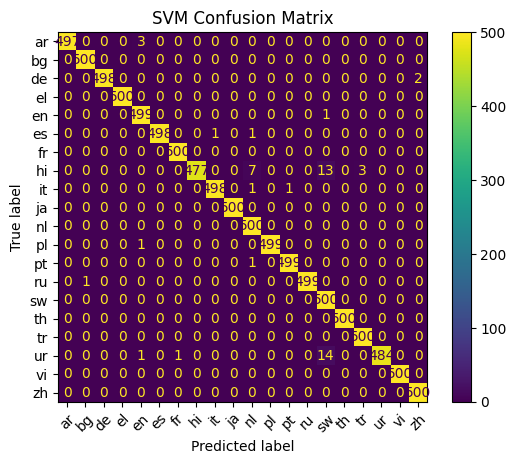

In [106]:
y_pred_svc = model_svc.predict(X_val)
acc_svc = accuracy_score(y_val, y_pred_svc)
print("Accuracy:", acc_svc)
cm_svc = confusion_matrix(y_val, y_pred_svc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=model_svc.classes_)
disp.plot(xticks_rotation=45)
plt.title("SVM Confusion Matrix")
plt.show()


## Multinomial Naïve Bayes

In [100]:

model_nb = MultinomialNB()
model_nb.fit(X, y)



,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


Accuracy: 0.9921


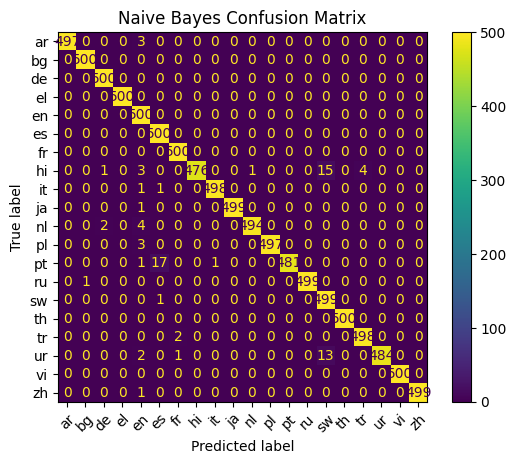

In [107]:
y_pred_nb = model_nb.predict(X_val)
acc_nb = accuracy_score(y_val, y_pred_nb)
print("Accuracy:", acc_nb)
cm_nb = confusion_matrix(y_val, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=model_nb.classes_)
disp.plot(xticks_rotation=45)
plt.title("Naive Bayes Confusion Matrix")
plt.show()


## Logistic Regression

In [102]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Accuracy: 0.9941


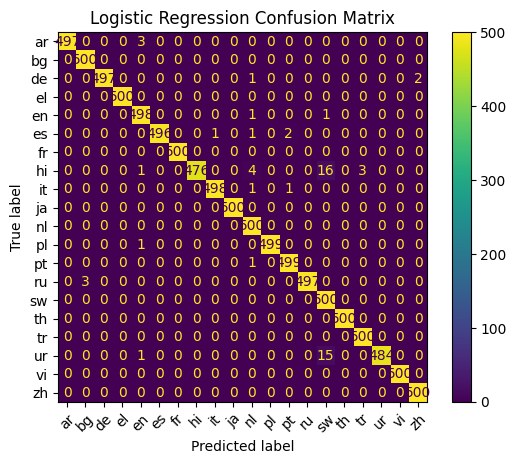

In [108]:
y_pred_lr = lr_model.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)
print("Accuracy:", acc_lr)
cm_lr = confusion_matrix(y_val, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr_model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## Random Forest

In [104]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Accuracy: 0.9931


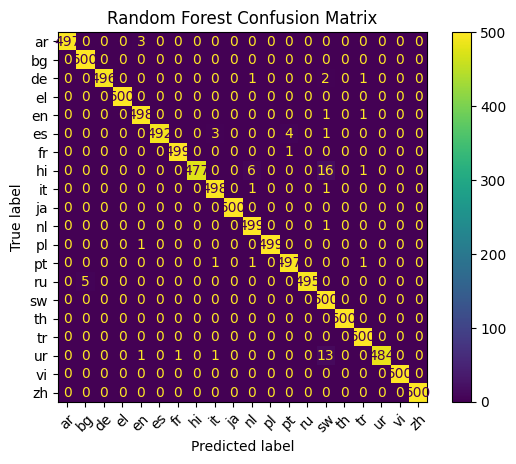

In [109]:
y_pred_rf = rf_model.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print("Accuracy:", acc_rf)
cm_rf = confusion_matrix(y_val, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp.plot(xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()


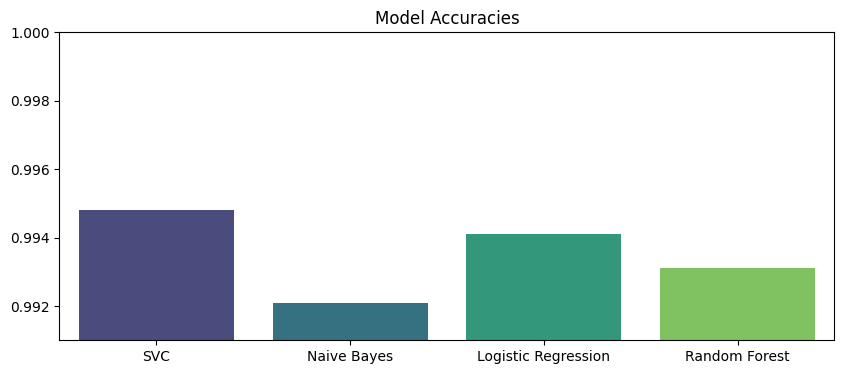

In [116]:
models = ['SVC', 'Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies = [acc_svc, acc_nb, acc_lr, acc_rf]
plt.figure(figsize=(10, 4))
sns.barplot(x=models, y=accuracies,hue=models,palette='viridis')
plt.ylim(0.991, 1)
plt.title("Model Accuracies")
plt.show()

## Apply Test set to Best Model

In [ ]:
y_pred_svc_test = model_svc.predict(X_test)
test_acc_svc = accuracy_score(y_test, y_pred_svc_test)
print("Accuracy on Test Set:", test_acc_svc)

Accuracy on Test Set: 0.9951


# Saving the Best Model

In [122]:
joblib.dump(model_svc, "models/language_svc_model.pkl")
joblib.dump(vectorizer, "models/tfidf_vectorizer.pkl")
print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


# Loading Model and Vectorizer

In [125]:
svc_model = joblib.load("models/language_svc_model.pkl")
vectorizer = joblib.load("models/tfidf_vectorizer.pkl")

In [126]:
# create a function to predict the language of a given text
def predict_language(text):
    text_vec = vectorizer.transform([text])
    prediction = svc_model.predict(text_vec)
    return prediction[0]

In [129]:
text = "This a samplt Sentence to test the language detection model."
predicted_language = predict_language(text)
print(f"The predicted language for the input text is: {predicted_language}")

The predicted language for the input text is: en
